# Generalized chi-square distribution — Getting started

The generalized chi-square variable is a quadratic form of a normal variable,
or equivalently, a linear sum of independent non-central chi-square variables
and a normal variable.

For function features and documentation, use Python's `help` (or `?` in
Jupyter), e.g.:

```python
help(gx2.gx2_to_norm_quad_params)
help(gx2.norm_quad_to_gx2_params)
help(gx2.stat)
help(gx2.rnd)
help(gx2.char)
help(gx2.cdf)
help(gx2.pdf)
help(gx2.inv)
```

Abhranil Das

Center for Perceptual Systems, University of Texas at Austin

Comments, questions, bugs to abhranil.das@utexas.edu

If you use this toolbox, please cite:
1. [Methods to integrate multinormals and compute classification measures.](https://arxiv.org/abs/2012.14331)
2. New methods to compute the generalized chi-square distribution: [journal](https://www.tandfonline.com/doi/abs/10.1080/00949655.2025.2501401) / [arxiv](https://arxiv.org/abs/2404.05062) (better formatting)


In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import gx2

# Keep this getting-started's output clean. The far-tail sections below
# deliberately push the methods past the limits of double precision, which
# would otherwise print expected underflow / log10-of-zero warnings.
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

np.random.seed(0)  # for reproducible random samples below

## Calculate mean and variance

In [2]:
# gx2 parameters
w = [1, -10, 2]
k = [1, 2, 3]
l = [2, 3, 7]
s = 5
m = 10

mu, v = gx2.stat(w, k, l, s, m)
print("mu =", mu)
print("v  =", v)

mu = -17.0
v  = 1771.0


## Generate random samples

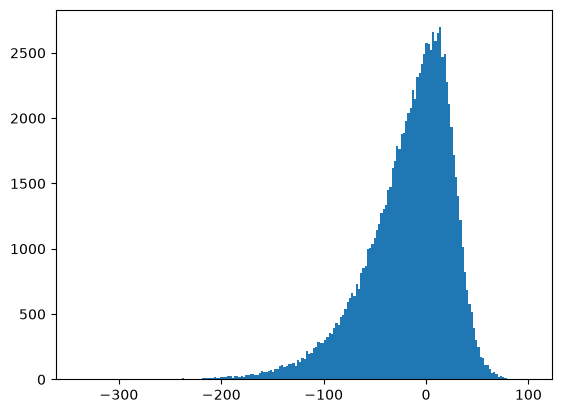

In [3]:
r = gx2.rnd(w, k, l, s, m, size=(1, int(1e5)))
plt.figure()
plt.hist(r.ravel(), bins=200, edgecolor='none')
plt.show()

## Compute PDF, CDF and inverse CDF with default methods

In [4]:
x = [10, 25]
f = gx2.pdf(x, w, k, l, s, m)
print("f =", f)
p = gx2.cdf(x, w, k, l, s, m)
print("p =", p)
# find the median by using the inverse CDF function:
x_med = gx2.inv(.5, w, k, l, s, m)
print("x_med =", x_med)
# Compute quantiles for cdf values of 1e-3 and 1e-2, by supplying their log10 values:
x_q = gx2.inv([-3, -2], w, k, l, s, m)
print("x_q =", x_q)
# verify that cdf values here are indeed 1e-3 and 1e-2
print("p =", gx2.cdf(x_q, w, k, l, s, m))
# Compute quantiles for complementary cdf values of 1e-3 and 1e-2, by supplying their log10 values:
x_q = gx2.inv([-3, -2], w, k, l, s, m, side='upper')
print("x_q (upper) =", x_q)
# verify that ccdf values here are indeed 1e-3 and 1e-2
print("p (upper) =", gx2.cdf(x_q, w, k, l, s, m, side='upper'))

f = [0.01205709 0.00879803]
p = [0.71497983 0.87899866]
x_med = -8.765662415017415
x_q = [-216.32581302 -149.23805331]
p = [0.001 0.01 ]


x_q (upper) = [69.48993534 51.03377986]
p (upper) = [0.001 0.01 ]


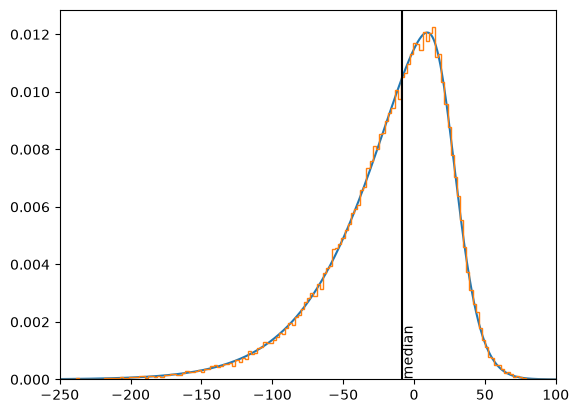

In [5]:
# compute the PDF over most of the span of the distribution.
# with the 'full' argument, the span x is computed automatically.
f, _, xf = gx2.pdf('full', w, k, l, s, m)

# now compare the sampled histogram with the computed PDF
plt.figure()
plt.plot(xf, f)
plt.hist(r.ravel(), bins=200, density=True, histtype='step')
plt.axvline(x_med, color='k')  # mark the computed median
plt.text(x_med, 0, 'median', rotation=90, va='bottom')
plt.xlim([-250, 100])
plt.show()

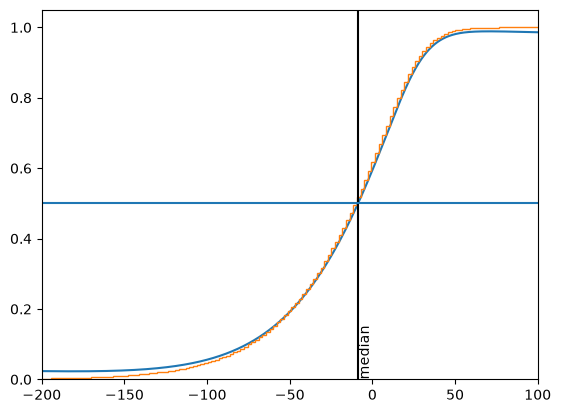

In [6]:
# compute CDF over most of the span of the distribution.
# the 'full' argument uses the IFFT method, good for quick rough plots,
# but less accurate (esp. for CDF) than some other methods
p, _, xp = gx2.cdf('full', w, k, l, s, m)

# now compare the sampled histogram with the computed CDF
plt.figure()
plt.plot(xp, p)
plt.hist(r.ravel(), bins=200, density=True, cumulative=True, histtype='step')
# mark the computed median, and verify that it sits at 0.5 on the vertical axis:
plt.axvline(x_med, color='k')
plt.text(x_med, 0, 'median', rotation=90, va='bottom')
plt.axhline(0.5)
plt.xlim([-200, 100])
plt.show()

## Compute CDF, PDF and inverse CDF with each exact method and its settings

### A non-elliptic distribution

x_bounds = [-142.69668996   24.81591319]


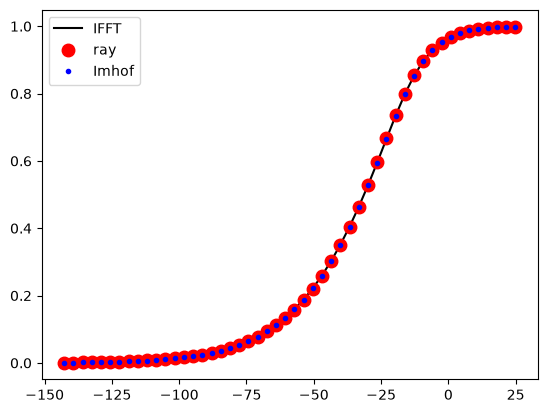

In [7]:
w = [-2, -5, 2]
k = [2, 1, 3]
l = [0, 4, 4]
s = 3
m = -20

# first find the quantile points at 0.1% in each tail
x_bounds = gx2.inv([0.001, 0.999], w, k, l, s, m)
print("x_bounds =", x_bounds)
# now compute within this range
x = np.linspace(x_bounds[0], x_bounds[1], 50)

# compute CDF
p_ifft = gx2.cdf(x, w, k, l, s, m, method='ifft')
p_imhof = gx2.cdf(x, w, k, l, s, m, method='imhof')
p_ray = gx2.cdf(x, w, k, l, s, m, method='ray', n_rays=int(1e4))

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, p_ifft, '-k', label='IFFT')
plt.plot(x, p_ray, 'or', markersize=9, label='ray')
plt.plot(x, p_imhof, '.b', markersize=6, label='Imhof')
plt.legend()
plt.show()

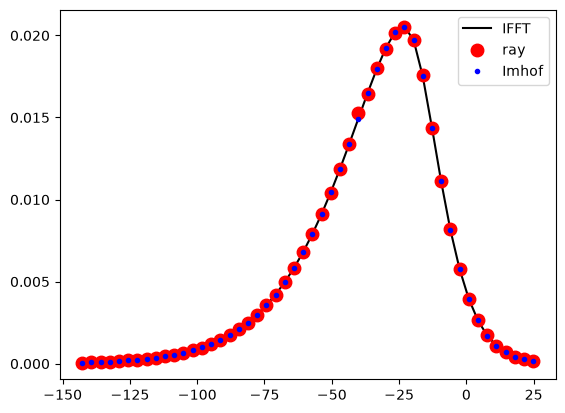

In [8]:
# compute PDF
f_ifft = gx2.pdf(x, w, k, l, s, m, method='ifft')
f_imhof = gx2.pdf(x, w, k, l, s, m, method='imhof')
f_ray = gx2.pdf(x, w, k, l, s, m, method='ray', n_rays=int(1e6))

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, f_ifft, '-k', label='IFFT')
plt.plot(x, f_ray, 'or', markersize=9, label='ray')
plt.plot(x, f_imhof, '.b', markersize=6, label='Imhof')
plt.legend()
plt.show()

In [9]:
# Compute quantiles for tiny cdf values of 1e-1000 and 1e-2000, by supplying
# their log10 values. Use a forward cdf method that can get down to such tiny values.
# Here we use the infinite-tail approximation.
x_q = gx2.inv([-1e3, -2e3], w, k, l, s, m, method='tail')
print("x_q =", x_q)
# now verify using an exact cdf method that cdf values here are indeed 1e-1000 and 1e-2000:
print("p =", gx2.cdf(x_q, w, k, l, s, m, method='ray', n_rays=int(1e7)))
# now do the same for the upper tail:
x_q = gx2.inv([-1e3, -2e3], w, k, l, s, m, side='upper', method='tail')
print("x_q (upper) =", x_q)
print("p (upper) =", gx2.cdf(x_q, w, k, l, s, m, side='upper', method='ray', n_rays=int(1e7)))

x_q = [-24365.14269438 -47950.03867407]


p = [-1002.00721503 -2006.17502979]
x_q (upper) = [ 9723.84451406 19159.3719629 ]


p (upper) = [-1001.2511481  -2003.53885456]


### An elliptic distribution

Here we can use Ruben's method too.

x_bounds = [-90.52584739 122.31996647]


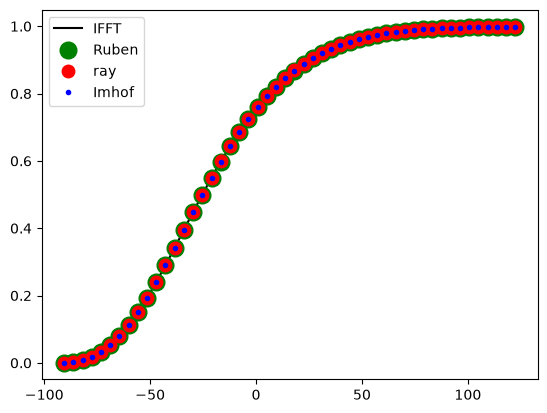

In [10]:
w = [3, 4, 5]
k = [1, 2, 3]
l = [2, 3, 7]
s = 0
m = -100

# first find the quantile points at 0.1% in each tail
x_bounds = gx2.inv([0.001, 0.999], w, k, l, s, m)
print("x_bounds =", x_bounds)
# now compute within this range
x = np.linspace(x_bounds[0], x_bounds[1], 50)

# compute CDF
p_ifft = gx2.cdf(x, w, k, l, s, m, method='ifft')
p_imhof = gx2.cdf(x, w, k, l, s, m, method='imhof')
p_ray = gx2.cdf(x, w, k, l, s, m, method='ray', n_rays=int(1e4))
p_ruben = gx2.cdf(x, w, k, l, s, m, method='ruben')

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, p_ifft, '-k', label='IFFT')
plt.plot(x, p_ruben, 'og', markersize=12, label='Ruben')
plt.plot(x, p_ray, 'or', markersize=9, label='ray')
plt.plot(x, p_imhof, '.b', markersize=6, label='Imhof')
plt.legend()
plt.show()

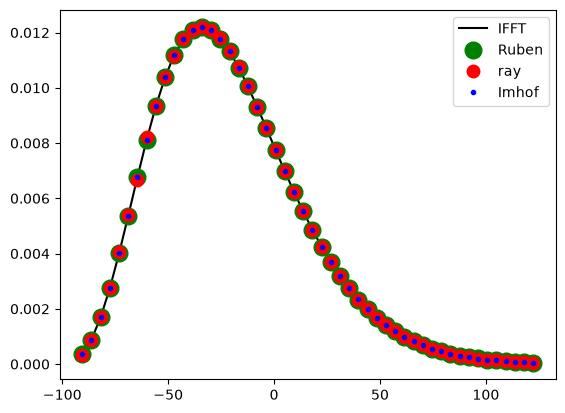

In [11]:
# compute PDF
f_ifft = gx2.pdf(x, w, k, l, s, m, method='ifft')
f_imhof = gx2.pdf(x, w, k, l, s, m, method='imhof')
f_ray = gx2.pdf(x, w, k, l, s, m, method='ray', n_rays=int(1e6))
f_ruben = gx2.pdf(x, w, k, l, s, m, method='ruben')

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, f_ifft, '-k', label='IFFT')
plt.plot(x, f_ruben, 'og', markersize=12, label='Ruben')
plt.plot(x, f_ray, 'or', markersize=9, label='ray')
plt.plot(x, f_imhof, '.b', markersize=6, label='Imhof')
plt.legend()
plt.show()

In [12]:
# Compute quantiles for tiny cdf values of 1e-1000 and 1e-2000, by supplying
# their log10 values. Use a forward cdf method that can get down to such tiny values.
# Here we use the ellipse approximation, with x_scale='log', which allows to specify
# log10 values of x measured from the finite tail m.
x_q = gx2.inv([-1e3, -2e3], w, k, l, s, m, method='ellipse', x_scale='log')
print("x_q =", x_q)
# this means that the computed quantiles are 1e-331 and 1e-664 above m

# now verify using the forward cdf method that cdf values here are indeed 1e-1000 and 1e-2000:
print("p =", gx2.cdf(x_q, w, k, l, s, m, method='ellipse', x_scale='log'))

x_q = [-331.27463875 -664.60797208]
p = [-1000. -2000.]


## Compute CDF and PDF in the far tails, using some tail approximation methods too

Ray, tail and Imhof methods are best for infinite tails.

### Compute CDF in an infinite lower tail

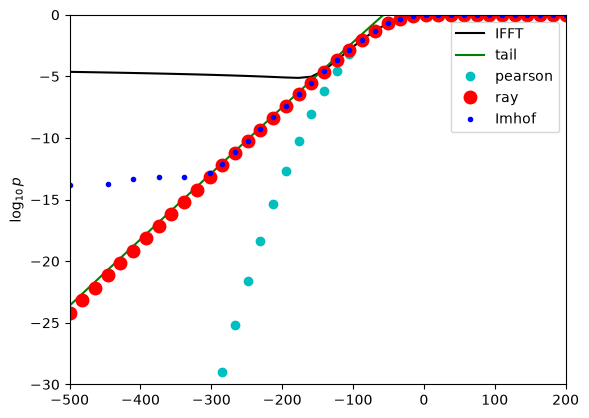

In [13]:
w = [1, 2, -3, -4]
k = [6, 5, 4, 3]
l = [5, 10, 0, 0]
s = 10
m = -50

x = np.linspace(-500, 200, 40)

p_ifft = gx2.cdf(x, w, k, l, s, m, method='ifft', span=1e7, n_grid=int(1e7))
p_imhof = gx2.cdf(x, w, k, l, s, m, method='imhof', AbsTol=0, RelTol=1e-10)
p_ray = gx2.cdf(x, w, k, l, s, m, method='ray', n_rays=int(1e6))
p_pearson = gx2.cdf(x, w, k, l, s, m, method='pearson')  # pearson sucks

# tail approximation for lower tail. Mentioning 'lower' is needed here.
# For output values that are too small for double precision, it returns
# their log10 values, which are negative.
p_tail = gx2.cdf(x, w, k, l, s, m, side='lower', method='tail')
p_tail = np.asarray(p_tail, dtype=float)
# convert all output values to their log10
p_tail[p_tail > 0] = np.log10(p_tail[p_tail > 0])

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, np.log10(p_ifft), '-k', label='IFFT')
plt.plot(x, p_tail, '-g', label='tail')
plt.plot(x, np.log10(p_pearson), '.c', markersize=12, label='pearson')
plt.plot(x, np.log10(p_ray), 'or', markersize=9, label='ray')
plt.plot(x, np.log10(p_imhof), '.b', markersize=6, label='Imhof')
plt.axis([-5e2, 200, -30, 0])
plt.legend()
plt.ylabel(r'$\log_{10} p$')
plt.show()

### Compute PDF in an infinite upper tail

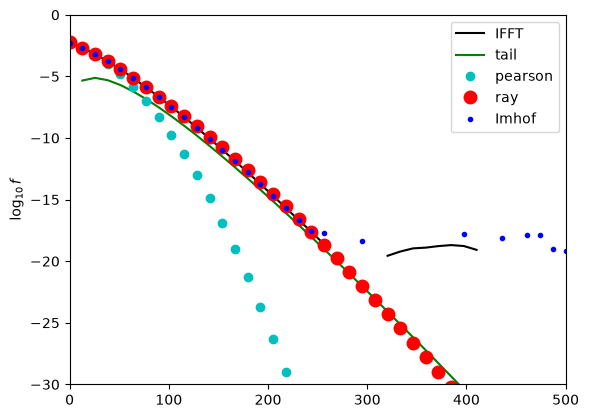

In [14]:
x = np.linspace(0, 500, 40)

f_ifft = gx2.pdf(x, w, k, l, s, m, method='ifft', span=1e7, n_grid=int(1e7))
f_imhof = gx2.pdf(x, w, k, l, s, m, method='imhof', AbsTol=0, RelTol=1e-1)
f_ray = gx2.pdf(x, w, k, l, s, m, method='ray', n_rays=int(1e6))
f_pearson = gx2.pdf(x, w, k, l, s, m, method='pearson')

# tail approximation for upper tail. Mentioning 'upper' is needed here.
f_tail = gx2.pdf(x, w, k, l, s, m, side='upper', method='tail')

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, np.log10(f_ifft), '-k', label='IFFT')
plt.plot(x, np.log10(np.asarray(f_tail, float)), '-g', label='tail')
plt.plot(x, np.log10(f_pearson), '.c', markersize=12, label='pearson')
plt.plot(x, np.log10(f_ray), 'or', markersize=9, label='ray')
plt.plot(x, np.log10(f_imhof), '.b', markersize=6, label='Imhof')
plt.axis([0, 500, -30, 0])
plt.legend()
plt.ylabel(r'$\log_{10} f$')
plt.show()

### Compute CDF in a finite lower tail

Ruben and ellipse methods are best for finite tails.

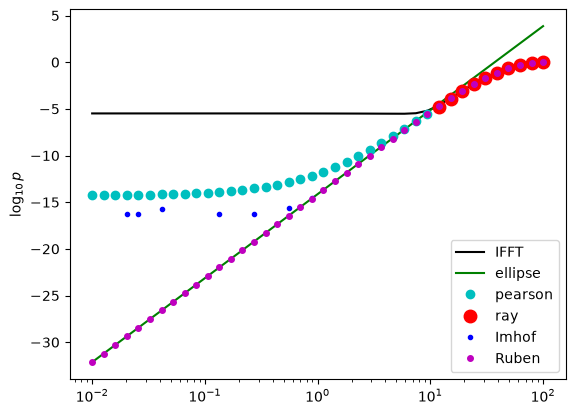

In [15]:
w = [1, 2, 3, 4]
k = [6, 5, 4, 3]
l = [5, 10, 0, 0]
s = 0
m = 0

x = np.logspace(-2, 2, 40)

p_ifft = gx2.cdf(x, w, k, l, s, m, method='ifft', span=1e7, n_grid=int(1e7))
p_imhof = gx2.cdf(x, w, k, l, s, m, method='imhof', AbsTol=0, RelTol=1e-10)
p_ruben = gx2.cdf(x, w, k, l, s, m, method='ruben')
p_ray = gx2.cdf(x, w, k, l, s, m, method='ray', n_rays=int(1e5))
p_pearson = gx2.cdf(x, w, k, l, s, m, method='pearson')
p_ellipse = gx2.cdf(x, w, k, l, s, m, method='ellipse')

# plot markers largest first, smallest last, so overlapping dots all stay visible
plt.figure()
plt.plot(x, np.log10(p_ifft), '-k', label='IFFT')
plt.plot(x, np.log10(np.asarray(p_ellipse, float)), '-g', label='ellipse')
plt.plot(x, np.log10(p_pearson), '.c', markersize=12, label='pearson')
plt.plot(x, np.log10(p_ray), 'or', markersize=9, label='ray')
plt.plot(x, np.log10(p_imhof), '.b', markersize=6, label='Imhof')
plt.plot(x, np.log10(p_ruben), 'om', markersize=4, label='Ruben')
plt.xscale('log')
plt.legend(loc='lower right')
plt.ylabel(r'$\log_{10} p$')
plt.show()

## Compute characteristic function

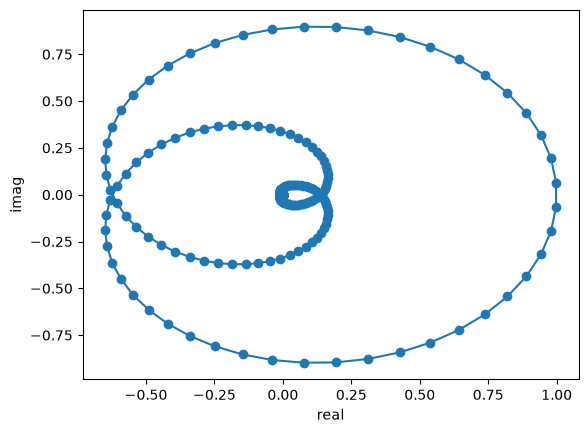

In [16]:
t = np.linspace(-1, 1, int(1e3))
phi = gx2.char(t, w, k, l, s, m)
plt.figure()
plt.plot(phi.real, phi.imag, '-o')
plt.xlabel('real'); plt.ylabel('imag')
plt.show()

## Distribution of quadratic form of a normal variable

Normal parameters:

In [17]:
mu = np.array([5, 6])      # mean
v = np.array([[2, 1], [1, 3]])  # covariance matrix

Sample normal random vectors:

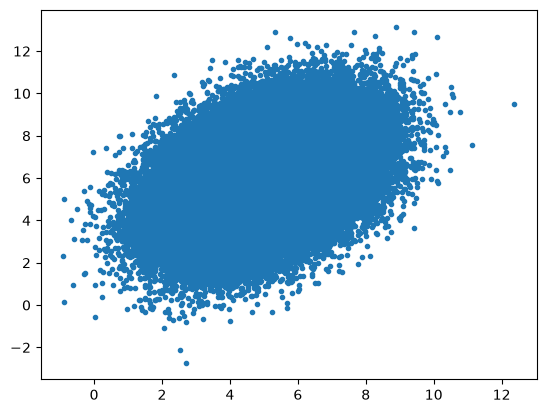

In [18]:
x = np.random.multivariate_normal(mu, v, int(1e5)).T
plt.figure()
plt.plot(x[0, :], x[1, :], '.')
plt.show()

Quadratic form $q(\mathbf{x})=(x_1+x_2)^2-x_1-1 =
[x_1;x_2]'\,[1\ 1; 1\ 1]\,[x_1;x_2] + [-1;0]'\,[x_1;x_2] - 1$

In [19]:
quad = {'q2': np.array([[1, 1], [1, 1]]),
        'q1': np.array([-1, 0]),
        'q0': -1}

Compute the quadratic form q for the sample of normal vectors:

In [20]:
q = np.sum(x * (quad['q2'] @ x), axis=0) + quad['q1'] @ x + quad['q0']

Get generalized chi-square parameters corresponding to this quadratic form:

In [21]:
w, k, l, s, m = gx2.norm_quad_to_gx2_params(mu, v, quad)
print("w      =", w)
print("k      =", k)
print("l=", l)
print("s      =", s)
print("m      =", m)

w      = [7.]
k      = [1.]
l= [16.61880466]
s      = 0.8451542547285165
m      = -1.3316326530612201


Compare the sampled and calculated distributions of q:

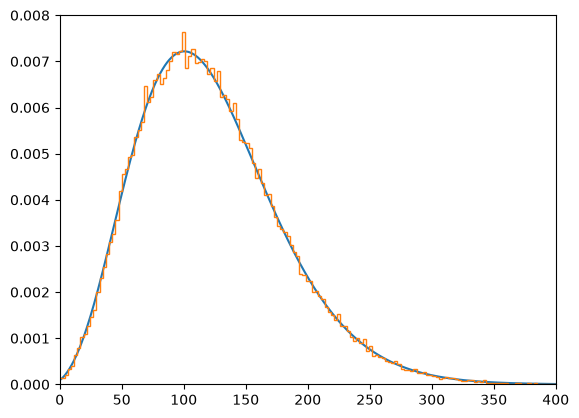

In [22]:
f, _, xf = gx2.pdf('full', w, k, l, s, m)
plt.figure()
plt.plot(xf, f)
plt.hist(q, bins=200, density=True, histtype='step')
plt.xlim([0, 400])
plt.show()

Compare the sampled and calculated means and variances:

In [23]:
mu_q, v_q = gx2.stat(w, k, l, s, m)
print([mu_q, q.mean()])
print([v_q, q.var()])

[122.0, np.float64(121.92202088814828)]
[3355.999999999998, np.float64(3324.8071301989507)]


Compare the sampled and calculated probabilities $p(q(\mathbf{x})<50)$:

In [24]:
print((q < 50).mean())
print(float(gx2.cdf(50, w, k, l, s, m)))

0.08404
0.08560283472030189


Find a canonical quadratic form of a standard multinormal corresponding to these generalized chi-square parameters:

In [25]:
quad = gx2.gx2_to_norm_quad_params(w, k, l, s, m)
print("q2 =\n", quad['q2'])
print("q1 =", quad['q1'])
print("q0 =", quad['q0'])

q2 =
 [[7. 0.]
 [0. 0.]]
q1 = [-57.07263542   0.84515425]
q0 = 115.0
